# 03. エピトープ状態のsignature reversal（HCC→正常肝）

**問い**（regulome論文の逆転を、エピトープ空間×HCC-正常リファレンスで）：
薬はHepG2(HCC)のエピトープ状態を **正常肝(PHH)に近づける(reversal)か、遠ざける(amplify)か？**

**設計**：
1. HCC方向ベクトル δ = HepG2 − PHH（glycogene baseline, 2nd paper）をエピトープ空間に射影
2. 各薬のエピトープ変化ベクトル（HepG2, コントラスト）
3. reversal = cos(薬, δ)。**負=正常へ戻す(治療的) / 正=HCC方向へ増幅**

正常リファレンス=PHH(primary human hepatocyte)。辞書=`RAW.GLYCOEPITOPE`(52ep, MAN0001-3含む)。

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import snowflake.connector as sc

con = sc.connect(account='DUETMBM-LL33279', user='KOREEDA', role='ACCOUNTADMIN',
    warehouse='BIOINFORMATICS_XS', authenticator='SNOWFLAKE_JWT',
    private_key_file=os.path.expanduser('~/.ssh/snowflake_rsa_key.pem'))
cur = con.cursor()
def norm_gene(g): return str(g).upper().replace('-','_')
print('connected')

connected


## 1. HCC方向ベクトル δ = HepG2 − PHH（glycogene baseline）

In [2]:
BASE='/Users/koreedatatsuya/research/lincs_glyco_2nd_paper/results/14_baseline_similarity_validation/phh_hepg2_glycogene_rank_by_timepoint.parquet'
b=pd.read_parquet(BASE)
b['gene']=b['gene'].map(norm_gene)
# timepoint横断でgene×cellのmedian_zscore中央値
prof=b.groupby(['cell','gene'])['median_zscore'].median().unstack('cell')
print('baseline cells:', list(prof.columns), ' genes:', prof.shape[0])
delta_gene=(prof['HEPG2']-prof['PHH']).dropna()   # HCC方向（+ = HCCで高い）
print('δ_gene (HepG2−PHH):', delta_gene.shape[0],'遺伝子')
print(delta_gene.sort_values().head(4).round(2).to_string(),'...',)
print(delta_gene.sort_values(ascending=False).head(4).round(2).to_string())

baseline cells: ['HEPG2', 'PHH']  genes: 385
δ_gene (HepG2−PHH): 385 遺伝子
gene
UGT1A9    -5.43
UGT2B15   -4.93
UGT1A4    -4.86
UGT1A6    -4.55 ...
gene
SLC2A3      3.74
HK2         3.52
SLC2A1      3.13
B4GALNT4    3.04


## 2. δ をエピトープ空間へ射影（step内max × step間min）
= 各エピトープが HCCで上がっているか下がっているか

In [3]:
steps=cur.execute('SELECT epitope_id,epitope_name,step_id,hgnc_symbol FROM RAW.GLYCOEPITOPE.EPITOPE_STEP_GENE').fetch_pandas_all()
steps.columns=[c.lower() for c in steps.columns]
steps['hgnc_symbol']=steps['hgnc_symbol'].map(norm_gene)
ep_steps=steps.groupby(['epitope_id','epitope_name','step_id'])['hgnc_symbol'].apply(list).reset_index()

def project_vec(sig):
    """gene→value Series を epitope→value に（step内max, step間min, 利用可能遺伝子のみ）"""
    out={}
    for (epid,epname),grp in ep_steps.groupby(['epitope_id','epitope_name']):
        sv=[]
        for _,r in grp.iterrows():
            gs=[g for g in r['hgnc_symbol'] if g in sig.index]
            if gs: sv.append(sig[gs].max())
        if sv: out[epname]=min(sv)
    return pd.Series(out)

delta_ep=project_vec(delta_gene)
print(f'δ_epitope: {len(delta_ep)}エピトープ')
print('\nHCCで上がるエピトープ top8:'); print(delta_ep.sort_values(ascending=False).head(8).round(2).to_string())
print('\nHCCで下がるエピトープ top8:'); print(delta_ep.sort_values().head(8).round(2).to_string())

δ_epitope: 52エピトープ

HCCで上がるエピトープ top8:
HNK-1                              2.19
beta1,6-GlcNAc Branching           1.81
N-Acetyl GM2                       1.80
GD2                                1.80
Chondroitin-6-Sulfate              1.52
Core Fucose (N-glycan alpha1,6)    1.16
T Antigen                          1.14
Chondroitin                        0.97

HCCで下がるエピトープ top8:
GM1b             -1.53
GD1a             -1.53
SSEA-4           -1.53
GT1b             -1.53
Monosialyl Gb5   -1.53
Asialo GM1       -0.76
GD1b             -0.76
GM1              -0.76


## 3. 各薬のエピトープ変化ベクトル（HepG2, コントラスト）

In [4]:
META={'value','canonical_smiles','cell','cmapid','compound_alias','dose','inchi_key','pertid','pertname','timepoint','sample_id'}
cols=set(r[0] for r in cur.execute("SELECT COLUMN_NAME FROM RAW.INFORMATION_SCHEMA.COLUMNS WHERE TABLE_SCHEMA='LINCS' AND TABLE_NAME='GLYCO_GENES_WIDE'").fetchall())
genes=sorted(set(steps['hgnc_symbol']) & {norm_gene(c) for c in cols})
# 逆引き: 正規化名→元列名
orig={norm_gene(c):c for c in cols}
sel=', '.join(['"pertname"']+[f'"{orig[g]}"' for g in genes])
df=cur.execute(f'SELECT {sel} FROM RAW.LINCS.GLYCO_GENES_WIDE WHERE "cell"=%s',('HEPG2',)).fetch_pandas_all()
df.columns=['pertname']+genes
for g in genes: df[g]=pd.to_numeric(df[g],errors='coerce')
cmean=df.groupby('pertname')[genes].mean()
cont=cmean-cmean.mean(0)             # コントラスト
# 各薬をエピトープ空間へ射影
D_ep=pd.DataFrame({pid: project_vec(cont.loc[pid]) for pid in cont.index}).T
print('D_ep (薬×エピトープ):', D_ep.shape)

D_ep (薬×エピトープ): (4704, 52)


## 4. reversal score = cos(薬, δ)  … 負=正常へ戻す

In [5]:
epc=sorted(set(D_ep.columns) & set(delta_ep.index))
dvec=delta_ep[epc].values
def cos(u):
    u=np.asarray(u,float); m=~np.isnan(u)
    if m.sum()<3: return np.nan
    uu,vv=u[m],dvec[m]
    nu,nv=np.linalg.norm(uu),np.linalg.norm(vv)
    return np.nan if nu==0 or nv==0 else float(uu@vv/(nu*nv))
rev=D_ep[epc].apply(cos,axis=1).dropna().rename('reversal')
print(f'{len(rev)}薬  reversal範囲[{rev.min():.2f},{rev.max():.2f}]  (負=正常化)')

# 承認薬注釈
ann=pd.read_csv('/Users/koreedatatsuya/research/lincs_glyco_2nd_paper/inputs/moa_target_master/compound_annotation_master.csv').set_index('compound_id')
ann=ann[~ann.index.duplicated()]; approved=ann[ann['MAX_PHASE']>=4]
rev_ap=rev[[i for i in rev.index if i in approved.index]]
print(f'承認薬 {len(rev_ap)}')

4704薬  reversal範囲[-0.59,0.73]  (負=正常化)


承認薬 456


In [6]:
def tab(idx):
    t=approved.loc[idx,['PREF_NAME','ATC_L1_desc','MOA']].copy()
    t.insert(0,'reversal',rev_ap[idx].round(3)); return t.reset_index(drop=True)
s=rev_ap.sort_values()
print('■ 正常肝へ戻す承認薬 top15（reversal最小=治療的方向）'); print(tab(s.head(15).index).to_string())
print('\n■ HCC方向へ増幅する承認薬 top10'); print(tab(s.tail(10).index).to_string())

■ 正常肝へ戻す承認薬 top15（reversal最小=治療的方向）
    reversal         PREF_NAME                                          ATC_L1_desc                                                                                                                                              MOA
0     -0.568      PROCAINAMIDE                                CARDIOVASCULAR SYSTEM                                                                                                                                              NaN
1     -0.509            NIACIN                                CARDIOVASCULAR SYSTEM                                                                                                                                              NaN
2     -0.456        HEXYLCAINE                                                  NaN                                                                                                                                              NaN
3     -0.445        METAXALONE                  

## 5. 図＋パーミュテーション（reversalが偶然でないか）

reversal広がり obs_sd=0.250  null_sd中央=0.126  perm_p=0.005


/var/folders/yb/qg8q9dxs50jft5_qv15b_2700000gn/T/ipykernel_43157/1764964100.py:22: UserWarning: Glyph 36000 (\N{CJK UNIFIED IDEOGRAPH-8CA0}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); fig.savefig('../../results/figures/hcc_epitope_reversal.png',dpi=150,bbox_inches='tight')
/var/folders/yb/qg8q9dxs50jft5_qv15b_2700000gn/T/ipykernel_43157/1764964100.py:22: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); fig.savefig('../../results/figures/hcc_epitope_reversal.png',dpi=150,bbox_inches='tight')
/var/folders/yb/qg8q9dxs50jft5_qv15b_2700000gn/T/ipykernel_43157/1764964100.py:22: UserWarning: Glyph 24120 (\N{CJK UNIFIED IDEOGRAPH-5E38}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); fig.savefig('../../results/figures/hcc_epitope_reversal.png',dpi=150,bbox_inches='tight')
/var/folders/yb/qg8q9dxs50jft5_qv15b_2700000gn/T/ipykernel_43157/1764964100.py:22: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}

/Users/koreedatatsuya/miniconda3/envs/glyco_pred/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12456 (\N{KATAKANA LETTER E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/koreedatatsuya/miniconda3/envs/glyco_pred/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12500 (\N{KATAKANA LETTER PI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/koreedatatsuya/miniconda3/envs/glyco_pred/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12488 (\N{KATAKANA LETTER TO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/koreedatatsuya/miniconda3/envs/glyco_pred/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/koreedatatsuya/miniconda3/envs

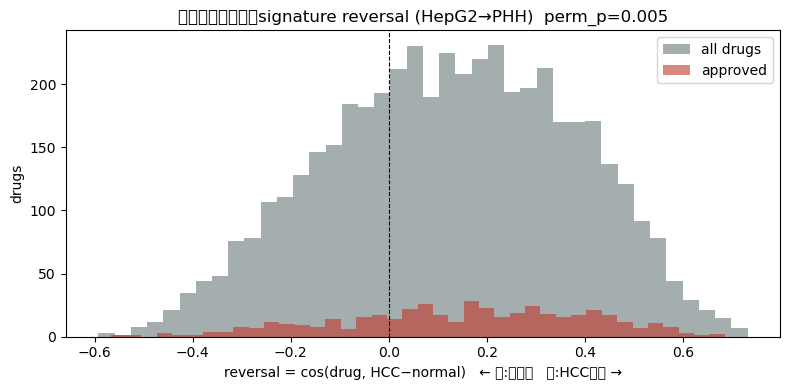

In [7]:
# ランダムなδでreversalの広がりが出るか（null）
rng=np.random.default_rng(0)
null_sd=[]
Dm=D_ep[epc].values
for _ in range(200):
    dv=dvec.copy(); rng.shuffle(dv)
    with np.errstate(invalid='ignore'):
        num=np.nansum(Dm*dv,axis=1); den=np.sqrt(np.nansum(Dm**2,axis=1))*np.linalg.norm(dv)
        c=num/den
    null_sd.append(np.nanstd(c))
obs_sd=rev.std()
p=(np.sum(np.array(null_sd)>=obs_sd)+1)/(len(null_sd)+1)
print(f'reversal広がり obs_sd={obs_sd:.3f}  null_sd中央={np.median(null_sd):.3f}  perm_p={p:.3f}')

fig,ax=plt.subplots(figsize=(8,4))
ax.hist(rev.values,bins=40,color='#7f8c8d',alpha=0.7,label='all drugs')
ax.hist(rev_ap.values,bins=40,color='#c0392b',alpha=0.6,label='approved')
ax.axvline(0,color='k',lw=0.8,ls='--')
ax.set_xlabel('reversal = cos(drug, HCC−normal)   ← 負:正常化   正:HCC増幅 →'); ax.set_ylabel('drugs')
ax.set_title(f'エピトープ状態のsignature reversal (HepG2→PHH)  perm_p={p:.3f}'); ax.legend()
os.makedirs('../../results/figures',exist_ok=True)
fig.tight_layout(); fig.savefig('../../results/figures/hcc_epitope_reversal.png',dpi=150,bbox_inches='tight')
plt.show()

In [8]:
os.makedirs('../../results/tables',exist_ok=True)
out=rev_ap.to_frame().join(approved[['PREF_NAME','ATC_L1_desc','MOA','MAX_PHASE']]).sort_values('reversal')
out.to_csv('../../results/tables/hcc_epitope_reversal_approved.csv')
delta_ep.sort_values().to_csv('../../results/tables/hcc_vs_normal_epitope_delta.csv')
print('saved reversal & delta tables'); con.close()

saved reversal & delta tables
